# Figura1

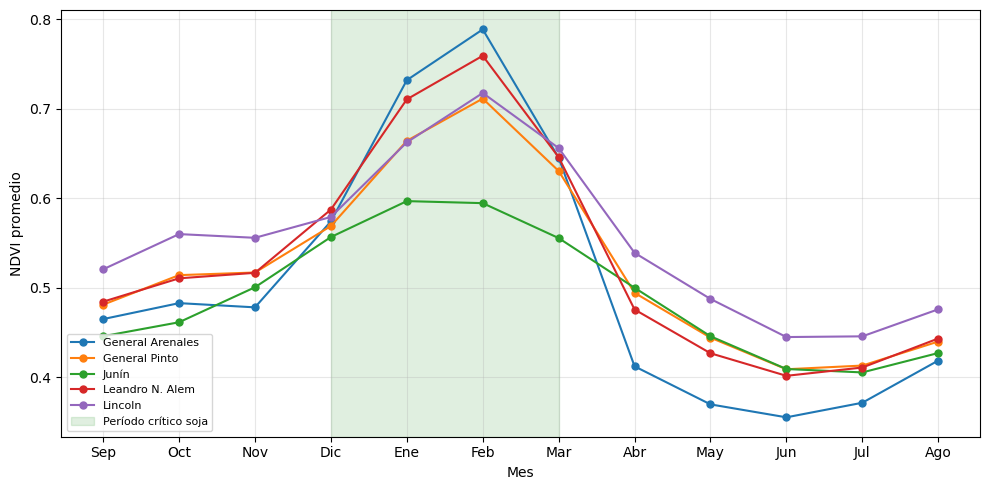

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT = Path.home() / "Documents" / "rinde-soja"
df_ndvi = pd.read_csv(PROJECT / "data" / "raw" / "ndvi" / "ndvi_modis_zona_coop_2000_2025.csv", parse_dates=["fecha"])

df_ndvi["mes"] = df_ndvi["fecha"].dt.month
orden_meses = [9,10,11,12,1,2,3,4,5,6,7,8]
meses_label = ["Sep","Oct","Nov","Dic","Ene","Feb","Mar","Abr","May","Jun","Jul","Ago"]

fig, ax = plt.subplots(figsize=(10, 5))
for partido in df_ndvi["partido"].unique():
    dp = df_ndvi[df_ndvi["partido"] == partido]
    ciclo = dp.groupby("mes")["ndvi"].mean().reindex(orden_meses)
    ax.plot(range(12), ciclo.values, marker="o", markersize=5, linewidth=1.5, label=partido)

ax.axvspan(3, 6, alpha=0.12, color="green", label="Período crítico soja")
ax.set_xticks(range(12))
ax.set_xticklabels(meses_label)
ax.set_ylabel("NDVI promedio")
ax.set_xlabel("Mes")
ax.legend(loc="lower left", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT / "outputs" / "figura1_ciclo_ndvi.png", dpi=200, bbox_inches="tight")
plt.show()

# Figura2

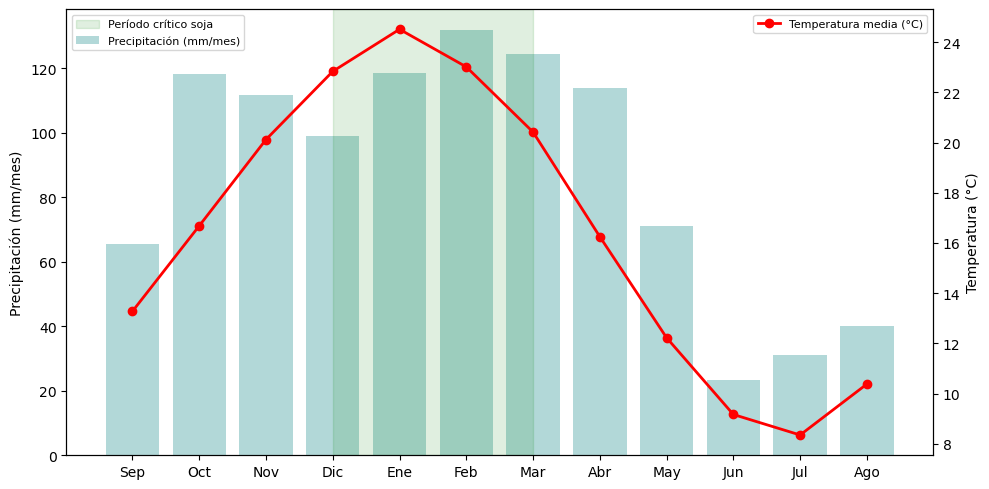

In [2]:
PROJECT = Path.home() / "Documents" / "rinde-soja"
df_clima = pd.read_csv(PROJECT / "data" / "raw" / "nasa_power" / "nasa_power_zona_coop_1999_2025.csv", parse_dates=["fecha"])

clima_mensual = df_clima.groupby(df_clima["fecha"].dt.month).agg({"T2M": "mean", "PRECTOTCORR": "mean"})
orden = [9,10,11,12,1,2,3,4,5,6,7,8]
meses = ["Sep","Oct","Nov","Dic","Ene","Feb","Mar","Abr","May","Jun","Jul","Ago"]
clima_ordenado = clima_mensual.reindex(orden)

fig, ax = plt.subplots(figsize=(10, 5))
ax2 = ax.twinx()
ax.bar(range(12), clima_ordenado["PRECTOTCORR"] * 30, alpha=0.3, color="teal", label="Precipitación (mm/mes)")
ax2.plot(range(12), clima_ordenado["T2M"], color="red", linewidth=2, marker="o", label="Temperatura media (°C)")
ax.axvspan(3, 6, alpha=0.12, color="green", label="Período crítico soja")
ax.set_xticks(range(12))
ax.set_xticklabels(meses)
ax.set_ylabel("Precipitación (mm/mes)")
ax2.set_ylabel("Temperatura (°C)")
ax.legend(loc="upper left", fontsize=8)
ax2.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig(PROJECT / "outputs" / "figura2_climatologia.png", dpi=200, bbox_inches="tight")
plt.show()

# Figura3

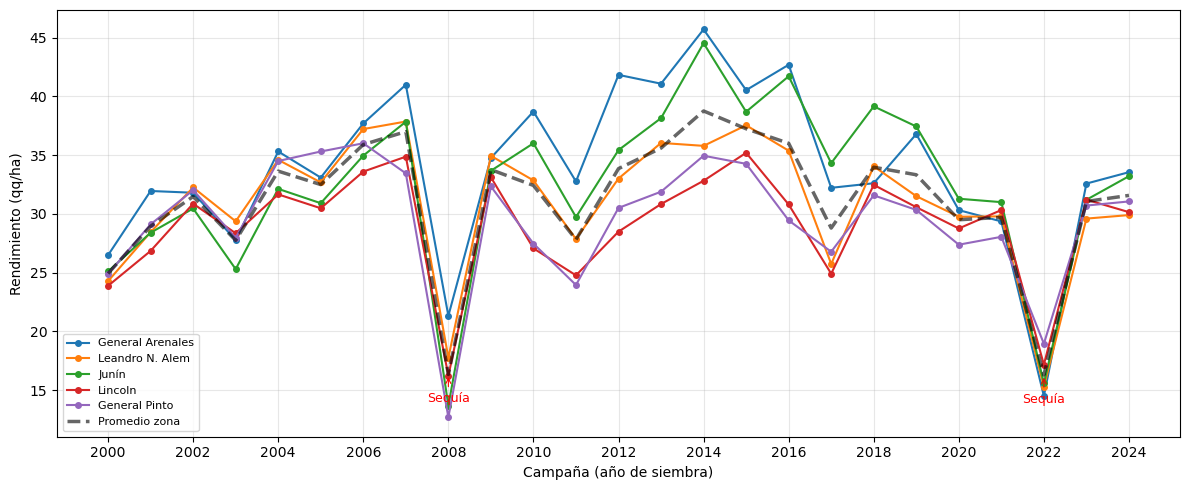

In [3]:
PROJECT = Path.home() / "Documents" / "rinde-soja"
df_rinde = pd.read_csv(PROJECT / "data" / "raw" / "magyp" / "soja-serie-1941-2024.csv")

PARTIDOS = ["General Arenales", "Leandro N. Alem", "Junín", "Lincoln", "General Pinto"]
zona = df_rinde[(df_rinde["provincia"] == "Buenos Aires") & (df_rinde["departamento"].isin(PARTIDOS)) & (df_rinde["anio"] >= 2000)].copy()
zona["rinde_qq_ha"] = zona["rendimiento_kgxha"] / 100

fig, ax = plt.subplots(figsize=(12, 5))
for partido in PARTIDOS:
    datos = zona[zona["departamento"] == partido].sort_values("anio")
    ax.plot(datos["anio"], datos["rinde_qq_ha"], marker="o", markersize=4, linewidth=1.5, label=partido)

promedio = zona.groupby("anio")["rinde_qq_ha"].mean()
ax.plot(promedio.index, promedio.values, color="black", linewidth=2.5, linestyle="--", alpha=0.6, label="Promedio zona")

for year, label in [(2008, "Sequía"), (2022, "Sequía")]:
    if year in promedio.index:
        ax.annotate(label, xy=(year, promedio[year]), xytext=(0, -20),
                   textcoords="offset points", fontsize=9, color="red", ha="center",
                   arrowprops=dict(arrowstyle="->", color="red", lw=0.8))

ax.set_xlabel("Campaña (año de siembra)")
ax.set_ylabel("Rendimiento (qq/ha)")
ax.legend(loc="lower left", fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xticks(range(2000, 2025, 2))
plt.tight_layout()
plt.savefig(PROJECT / "outputs" / "figura3_rinde_historico.png", dpi=200, bbox_inches="tight")
plt.show()

# Figura4

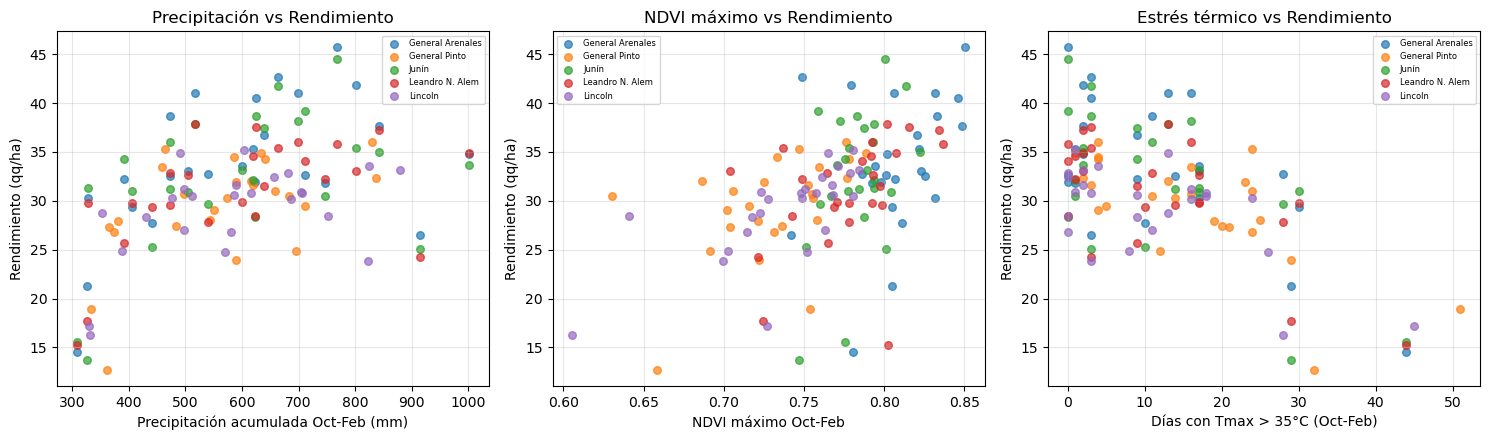

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT = Path.home() / "Documents" / "rinde-soja"
df = pd.read_csv(PROJECT / "data" / "processed" / "dataset_modelado_soja.csv")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

partidos = df["partido"].unique()
for partido in partidos:
    dp = df[df["partido"] == partido]
    axes[0].scatter(dp["precip_acum_oct_feb"], dp["rinde_qq_ha"], s=30, alpha=0.7, label=partido)
    axes[1].scatter(dp["ndvi_max_oct_feb"], dp["rinde_qq_ha"], s=30, alpha=0.7, label=partido)
    axes[2].scatter(dp["dias_calor_extremo_oct_feb"], dp["rinde_qq_ha"], s=30, alpha=0.7, label=partido)

axes[0].set(xlabel="Precipitación acumulada Oct-Feb (mm)", ylabel="Rendimiento (qq/ha)", title="Precipitación vs Rendimiento")
axes[1].set(xlabel="NDVI máximo Oct-Feb", ylabel="Rendimiento (qq/ha)", title="NDVI máximo vs Rendimiento")
axes[2].set(xlabel="Días con Tmax > 35°C (Oct-Feb)", ylabel="Rendimiento (qq/ha)", title="Estrés térmico vs Rendimiento")

for ax in axes:
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT / "outputs" / "figura4_eda_features.png", dpi=200, bbox_inches="tight")
plt.show()

# Tabla1 5.2

BASELINE CLIMATOLÓGICO:
  MAE : 4.04 qq/ha
  RMSE: 6.15 qq/ha
  R²  : -0.047


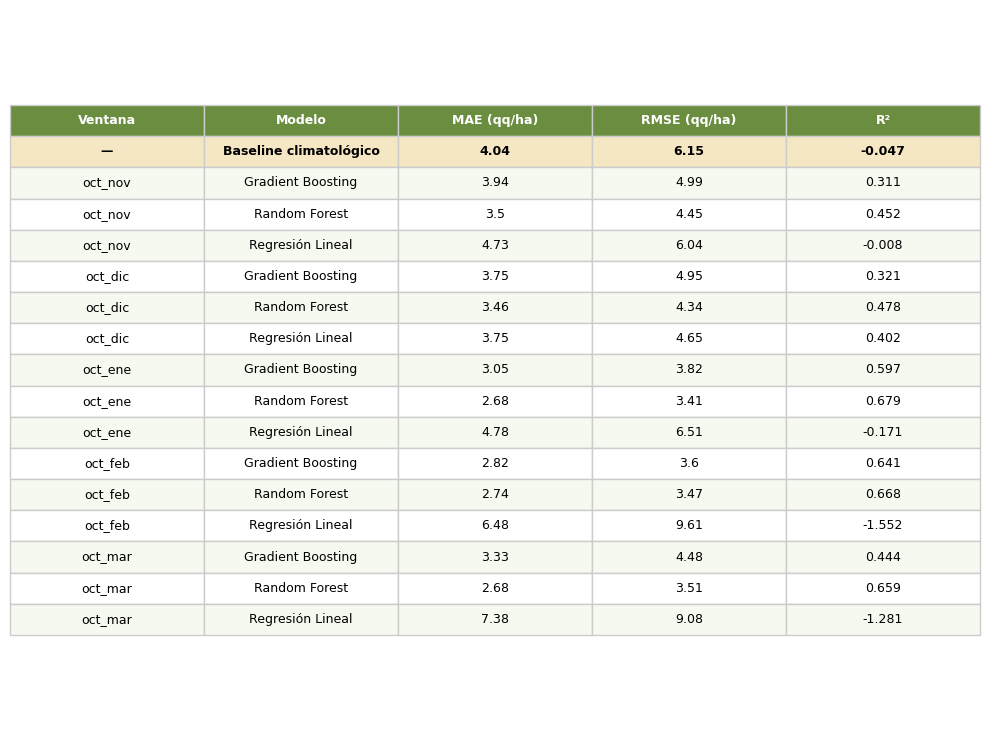


Mejora de RF oct_ene sobre baseline: 1.36 qq/ha de MAE


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pathlib import Path

PROJECT = Path.home() / "Documents" / "rinde-soja"
df = pd.read_csv(PROJECT / "data" / "processed" / "dataset_modelado_soja.csv")
results = pd.read_csv(PROJECT / "outputs" / "resultados_modelos.csv")

# Calcular baseline climatológico (promedio histórico por partido, walk-forward)
filas_base = []
for test_year in range(2016, 2025):
    train = df[df["campana"] < test_year]
    test = df[df["campana"] == test_year]
    promedios = train.groupby("partido")["rinde_qq_ha"].mean()
    for _, row in test.iterrows():
        filas_base.append({
            "real": row["rinde_qq_ha"],
            "pred": promedios[row["partido"]]
        })

base = pd.DataFrame(filas_base)
base_mae = mean_absolute_error(base["real"], base["pred"])
base_rmse = np.sqrt(mean_squared_error(base["real"], base["pred"]))
base_r2 = r2_score(base["real"], base["pred"])

print(f"BASELINE CLIMATOLÓGICO:")
print(f"  MAE : {base_mae:.2f} qq/ha")
print(f"  RMSE: {base_rmse:.2f} qq/ha")
print(f"  R²  : {base_r2:.3f}")

# Agregar baseline al dataframe de resultados (una fila por ventana no aplica, va como fila única)
baseline_row = pd.DataFrame([{
    "ventana": "—",
    "modelo": "Baseline climatológico",
    "MAE": round(base_mae, 2),
    "RMSE": round(base_rmse, 2),
    "R2": round(base_r2, 3),
}])

# Ordenar modelos
orden_ventanas = ["oct_nov", "oct_dic", "oct_ene", "oct_feb", "oct_mar"]
results["ventana"] = pd.Categorical(results["ventana"], categories=orden_ventanas, ordered=True)
results = results.sort_values(["ventana", "modelo"])

# Preparar tabla: baseline arriba, después los modelos por ventana
tabla_modelos = results[["ventana", "modelo", "MAE", "RMSE", "R2"]].copy()
tabla_modelos.columns = ["Ventana", "Modelo", "MAE (qq/ha)", "RMSE (qq/ha)", "R²"]

tabla_baseline = baseline_row[["ventana", "modelo", "MAE", "RMSE", "R2"]].copy()
tabla_baseline.columns = ["Ventana", "Modelo", "MAE (qq/ha)", "RMSE (qq/ha)", "R²"]

tabla = pd.concat([tabla_baseline, tabla_modelos], ignore_index=True)

# Generar imagen
fig, ax = plt.subplots(figsize=(10, 7.5))
ax.axis('off')
t = ax.table(cellText=tabla.values, colLabels=tabla.columns, cellLoc='center', loc='center')
t.auto_set_font_size(False)
t.set_fontsize(9)
t.scale(1, 1.5)

for (row, col), cell in t.get_celld().items():
    if row == 0:
        cell.set_facecolor('#6A8D3F')
        cell.set_text_props(color='white', fontweight='bold')
    elif row == 1:  # Fila del baseline
        cell.set_facecolor('#F5E6C4')
        cell.set_text_props(fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#F5F9F0')
    cell.set_edgecolor('#CCCCCC')

plt.tight_layout()
plt.savefig(PROJECT / "outputs" / "tabla1_modelos.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

# Imprimir mejora sobre baseline para oct_ene
rf_oct_ene = results[(results["ventana"] == "oct_ene") & (results["modelo"] == "Random Forest")]
mejora = base_mae - rf_oct_ene["MAE"].values[0]
print(f"\nMejora de RF oct_ene sobre baseline: {mejora:.2f} qq/ha de MAE")

# Figura5

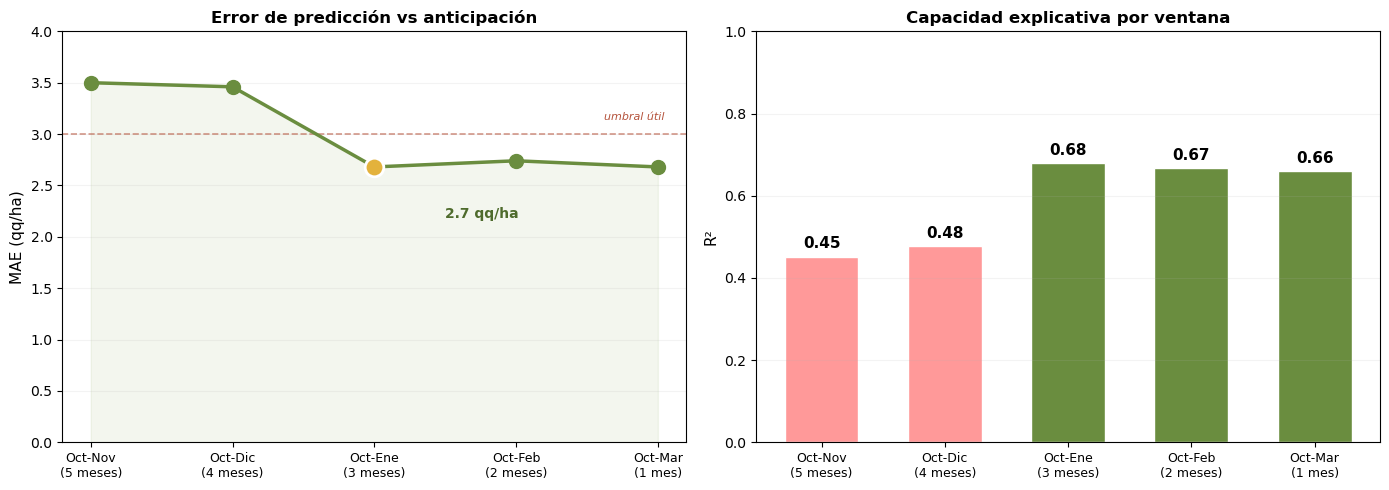

In [2]:
PROJECT = Path.home() / "Documents" / "rinde-soja"
results = pd.read_csv(PROJECT / "outputs" / "resultados_modelos.csv")

# Filtrar solo Random Forest
rf = results[results["modelo"] == "Random Forest"].reset_index(drop=True)

labels_x = ["Oct-Nov\n(5 meses)", "Oct-Dic\n(4 meses)", "Oct-Ene\n(3 meses)", "Oct-Feb\n(2 meses)", "Oct-Mar\n(1 mes)"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE por ventana
ax = axes[0]
ax.plot(range(5), rf["MAE"], marker="o", linewidth=2.5, color="#6A8D3F", markersize=10, zorder=5)
ax.fill_between(range(5), 0, rf["MAE"], alpha=0.1, color="#8BAE5D")
ax.axhline(y=3, color="#B5533C", linestyle="--", alpha=0.6, linewidth=1.2)
ax.text(4.05, 3.12, "umbral útil", fontsize=8, color="#B5533C", va="bottom", ha="right", style="italic")
ax.scatter([2], [rf.iloc[2]["MAE"]], s=180, color="#E3B23C", zorder=6, edgecolors="white", linewidths=2)
ax.annotate(f'{rf.iloc[2]["MAE"]:.1f} qq/ha', xy=(2, rf.iloc[2]["MAE"]),
           xytext=(2.5, rf.iloc[2]["MAE"]-0.5), fontsize=10, fontweight="bold", color="#4E6B2C")
ax.set_xticks(range(5))
ax.set_xticklabels(labels_x, fontsize=9)
ax.set_ylabel("MAE (qq/ha)", fontsize=11)
ax.set_title("Error de predicción vs anticipación", fontsize=12, fontweight="bold")
ax.set_ylim(0, 4)
ax.grid(True, alpha=0.15, axis="y")

# R² por ventana
ax = axes[1]
colors = ["#ff9999" if r < 0.5 else "#99cc99" if r < 0.65 else "#6A8D3F" for r in rf["R2"]]
ax.bar(range(5), rf["R2"], color=colors, edgecolor="white", width=0.6)
ax.set_xticks(range(5))
ax.set_xticklabels(labels_x, fontsize=9)
ax.set_ylabel("R²", fontsize=11)
ax.set_title("Capacidad explicativa por ventana", fontsize=12, fontweight="bold")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.15, axis="y")
for i, r2 in enumerate(rf["R2"]):
    ax.text(i, r2 + 0.02, f"{r2:.2f}", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig(PROJECT / "outputs" / "figura5_anticipacion.png", dpi=200, bbox_inches="tight")
plt.show()

# Figura6

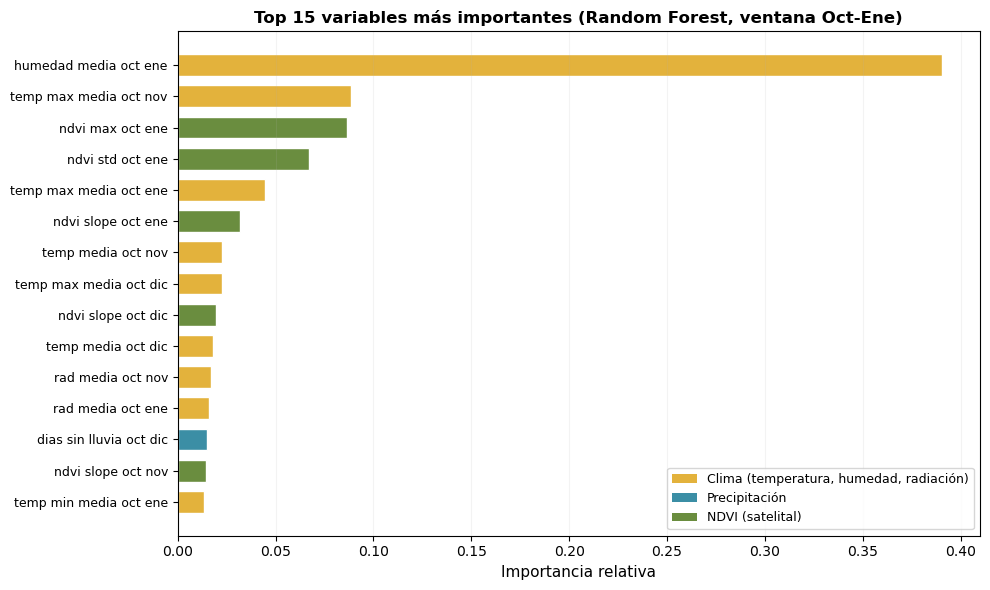

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from pathlib import Path

PROJECT = Path.home() / "Documents" / "rinde-soja"
df = pd.read_csv(PROJECT / "data" / "processed" / "dataset_modelado_soja.csv")

META_COLS = ["campana", "partido", "rinde_qq_ha", "superficie_sembrada_ha", "superficie_cosechada_ha"]
VENTANAS = ["oct_nov", "oct_dic", "oct_ene"]

def get_features_ventana(ventana):
    idx = VENTANAS.index(ventana)
    vd = VENTANAS[:idx+1]
    return [c for c in df.columns if c not in META_COLS and any(c.endswith(v) for v in vd)]

features = get_features_ventana("oct_ene")
scaler = StandardScaler()
X = scaler.fit_transform(df[features])
y = df["rinde_qq_ha"].values

model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
model.fit(X, y)

# Importancia de variables
importancias = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
top15 = importancias.tail(15)

# Colorear por tipo de variable
colores = []
for nombre in top15.index:
    if "ndvi" in nombre:
        colores.append("#6A8D3F")   # verde: satelital
    elif "precip" in nombre or "dias_sin_lluvia" in nombre:
        colores.append("#3B8EA5")   # azul: precipitación
    else:
        colores.append("#E3B23C")   # dorado: temperatura/clima

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(top15)), top15.values, color=colores, edgecolor="white", height=0.7)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels([n.replace("_", " ") for n in top15.index], fontsize=9)
ax.set_xlabel("Importancia relativa", fontsize=11)
ax.set_title("Top 15 variables más importantes (Random Forest, ventana Oct-Ene)", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.15, axis="x")

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#E3B23C", label="Clima (temperatura, humedad, radiación)"),
    Patch(facecolor="#3B8EA5", label="Precipitación"),
    Patch(facecolor="#6A8D3F", label="NDVI (satelital)"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig(PROJECT / "outputs" / "figura6_importancia_variables.png", dpi=200, bbox_inches="tight")
plt.show()

# Tabla2 5.5

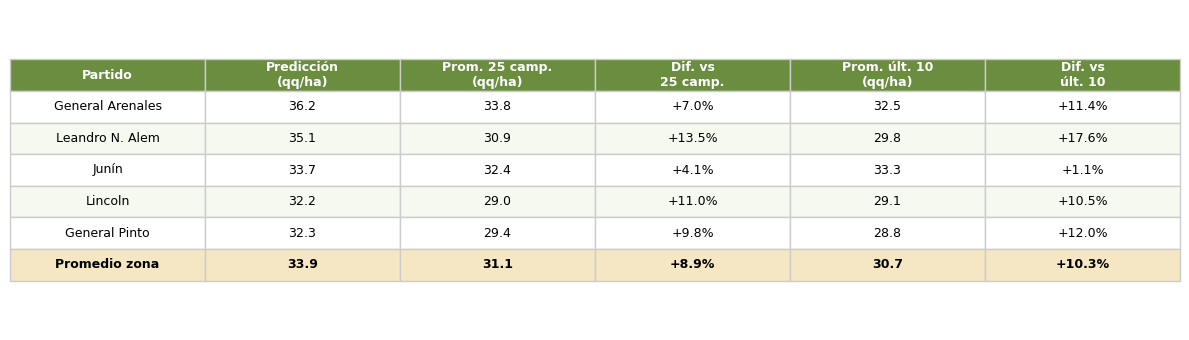


Promedio zonal últimas 10 campañas: 30.7 qq/ha
Diferencia predicción vs últimas 10: +10.3%

Detalle por partido:
  General Arenales       | Pred: 36.2 | Prom25: 33.8 (+7.0%) | Prom10: 32.5 (+11.4%)
  Leandro N. Alem        | Pred: 35.1 | Prom25: 30.9 (+13.5%) | Prom10: 29.8 (+17.6%)
  Junín                  | Pred: 33.7 | Prom25: 32.4 (+4.1%) | Prom10: 33.3 (+1.1%)
  Lincoln                | Pred: 32.2 | Prom25: 29.0 (+11.0%) | Prom10: 29.1 (+10.5%)
  General Pinto          | Pred: 32.3 | Prom25: 29.4 (+9.8%) | Prom10: 28.8 (+12.0%)
  Promedio zona          | Pred: 33.9 | Prom25: 31.1 (+8.9%) | Prom10: 30.7 (+10.3%)


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT = Path.home() / "Documents" / "rinde-soja"
df = pd.read_csv(PROJECT / "data" / "processed" / "dataset_modelado_soja.csv")

# Promedios por partido
hist_25 = df.groupby("partido")["rinde_qq_ha"].mean()
hist_10 = df[df["campana"] >= 2015].groupby("partido")["rinde_qq_ha"].mean()

# Predicciones 2025/26
pred_2526 = {
    "General Arenales": 36.2,
    "Leandro N. Alem": 35.1,
    "Junín": 33.7,
    "Lincoln": 32.2,
    "General Pinto": 32.3,
}

# Armar tabla
filas = []
for partido in ["General Arenales", "Leandro N. Alem", "Junín", "Lincoln", "General Pinto"]:
    pred = pred_2526[partido]
    prom25 = hist_25[partido]
    prom10 = hist_10[partido]
    diff25 = ((pred - prom25) / prom25 * 100)
    diff10 = ((pred - prom10) / prom10 * 100)
    filas.append([partido, f"{pred:.1f}", f"{prom25:.1f}", f"+{diff25:.1f}%", f"{prom10:.1f}", f"+{diff10:.1f}%"])

# Fila promedio zona
pred_zona = sum(pred_2526.values()) / len(pred_2526)
prom25_zona = hist_25.mean()
prom10_zona = hist_10.mean()
diff25_zona = ((pred_zona - prom25_zona) / prom25_zona * 100)
diff10_zona = ((pred_zona - prom10_zona) / prom10_zona * 100)
filas.append(["Promedio zona", f"{pred_zona:.1f}", f"{prom25_zona:.1f}", f"+{diff25_zona:.1f}%", f"{prom10_zona:.1f}", f"+{diff10_zona:.1f}%"])

# Generar tabla como imagen
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.axis('off')

columnas = ["Partido", "Predicción\n(qq/ha)", "Prom. 25 camp.\n(qq/ha)", "Dif. vs\n25 camp.", "Prom. últ. 10\n(qq/ha)", "Dif. vs\núlt. 10"]
t = ax.table(cellText=filas, colLabels=columnas, cellLoc='center', loc='center')
t.auto_set_font_size(False)
t.set_fontsize(9)
t.scale(1, 1.6)

for (row, col), cell in t.get_celld().items():
    if row == 0:
        cell.set_facecolor('#6A8D3F')
        cell.set_text_props(color='white', fontweight='bold')
    elif row == len(filas):
        cell.set_facecolor('#F5E6C4')
        cell.set_text_props(fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#F5F9F0')
    cell.set_edgecolor('#CCCCCC')

plt.tight_layout()
plt.savefig(PROJECT / "outputs" / "tabla2_prediccion_2526.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

# Imprimir valores para completar el texto
print(f"\nPromedio zonal últimas 10 campañas: {prom10_zona:.1f} qq/ha")
print(f"Diferencia predicción vs últimas 10: +{diff10_zona:.1f}%")
print(f"\nDetalle por partido:")
for fila in filas:
    print(f"  {fila[0]:22s} | Pred: {fila[1]} | Prom25: {fila[2]} ({fila[3]}) | Prom10: {fila[4]} ({fila[5]})")

# Figura7

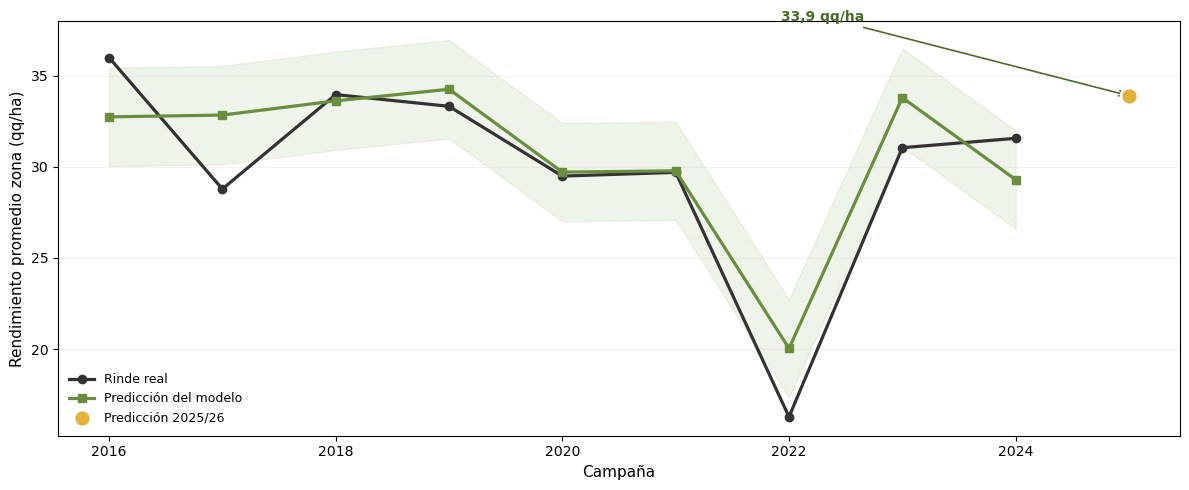

In [5]:
PROJECT = Path.home() / "Documents" / "rinde-soja"
df = pd.read_csv(PROJECT / "data" / "processed" / "dataset_modelado_soja.csv")
preds = pd.read_csv(PROJECT / "outputs" / "predicciones_rf_oct_ene.csv")

# Promedio zona por campaña: real vs predicho
resumen = preds.groupby("campana").agg(
    real=("rinde_real", "mean"),
    pred=("rinde_pred", "mean")
).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(resumen["campana"], resumen["real"], marker="o", linewidth=2.3, color="#333333", markersize=6, label="Rinde real", zorder=4)
ax.plot(resumen["campana"], resumen["pred"], marker="s", linewidth=2.3, color="#6A8D3F", markersize=6, label="Predicción del modelo", zorder=4)
ax.fill_between(resumen["campana"], resumen["pred"]-2.7, resumen["pred"]+2.7, alpha=0.13, color="#8BAE5D")

# Predicción 2025/26
ax.scatter([2025], [33.9], color="#E3B23C", s=150, zorder=6, edgecolors="white", linewidths=2, label="Predicción 2025/26")
ax.annotate("33,9 qq/ha", xy=(2025, 33.9), xytext=(2022.3, 38),
           fontsize=10, fontweight="bold", color="#4E6B2C", ha="center",
           arrowprops=dict(arrowstyle="->", color="#4E6B2C", lw=1.2))

ax.set_xlabel("Campaña", fontsize=11)
ax.set_ylabel("Rendimiento promedio zona (qq/ha)", fontsize=11)
ax.legend(fontsize=9, loc="lower left", frameon=False)
ax.grid(True, alpha=0.15, axis="y")
plt.tight_layout()
plt.savefig(PROJECT / "outputs" / "figura7_prediccion_2526.png", dpi=200, bbox_inches="tight")
plt.show()